In [ ]:
import pandas as pd
from sklearn.datasets import fetch_california_housing

# Load the California housing dataset
california_housing = fetch_california_housing(as_frame=True)
df_california = california_housing.frame

In [ ]:
# Display the first 5 rows of the DataFrame
#display(df_california.head())

In [ ]:
# Display the entire DataFrame
display(df_california)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


In [ ]:
# Print the sum of null values for each column
print("Null values in each column:")
print(df_california.isnull().sum())

Null values in each column:
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64


In [ ]:
# Print the number of duplicate rows
num_duplicates = df_california.duplicated().sum()
print(f"Number of duplicate rows: {num_duplicates}")

# Display the duplicate rows if any exist
if num_duplicates > 0:
    print("\nDuplicate rows (showing all occurrences):")
    display(df_california[df_california.duplicated(keep=False)])
else:
    print("No duplicate rows found.")

Number of duplicate rows: 0
No duplicate rows found.


### Outlier Detection for Original DataFrame (Before Transformation/Imputation)

In [ ]:
print("Outliers in df_california (Original DataFrame):")

numerical_cols_original = df_california.select_dtypes(include=['number']).columns

for col in numerical_cols_original:
    Q1 = df_california[col].quantile(0.25)
    Q3 = df_california[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers_original = df_california[(df_california[col] < lower_bound) | (df_california[col] > upper_bound)]

    if not outliers_original.empty:
        print(f"\nNumber of outliers in '{col}': {len(outliers_original)}")
        # Optionally display outliers_original[[col]] if needed, but only count was requested
    else:
        print(f"\nNo outliers found in '{col}' based on IQR method.")

Outliers in df_california (Original DataFrame):

Number of outliers in 'MedInc': 681

No outliers found in 'HouseAge' based on IQR method.

Number of outliers in 'AveRooms': 511

Number of outliers in 'AveBedrms': 1424

Number of outliers in 'Population': 1196

Number of outliers in 'AveOccup': 711

No outliers found in 'Latitude' based on IQR method.

No outliers found in 'Longitude' based on IQR method.

Number of outliers in 'MedHouseVal': 1071


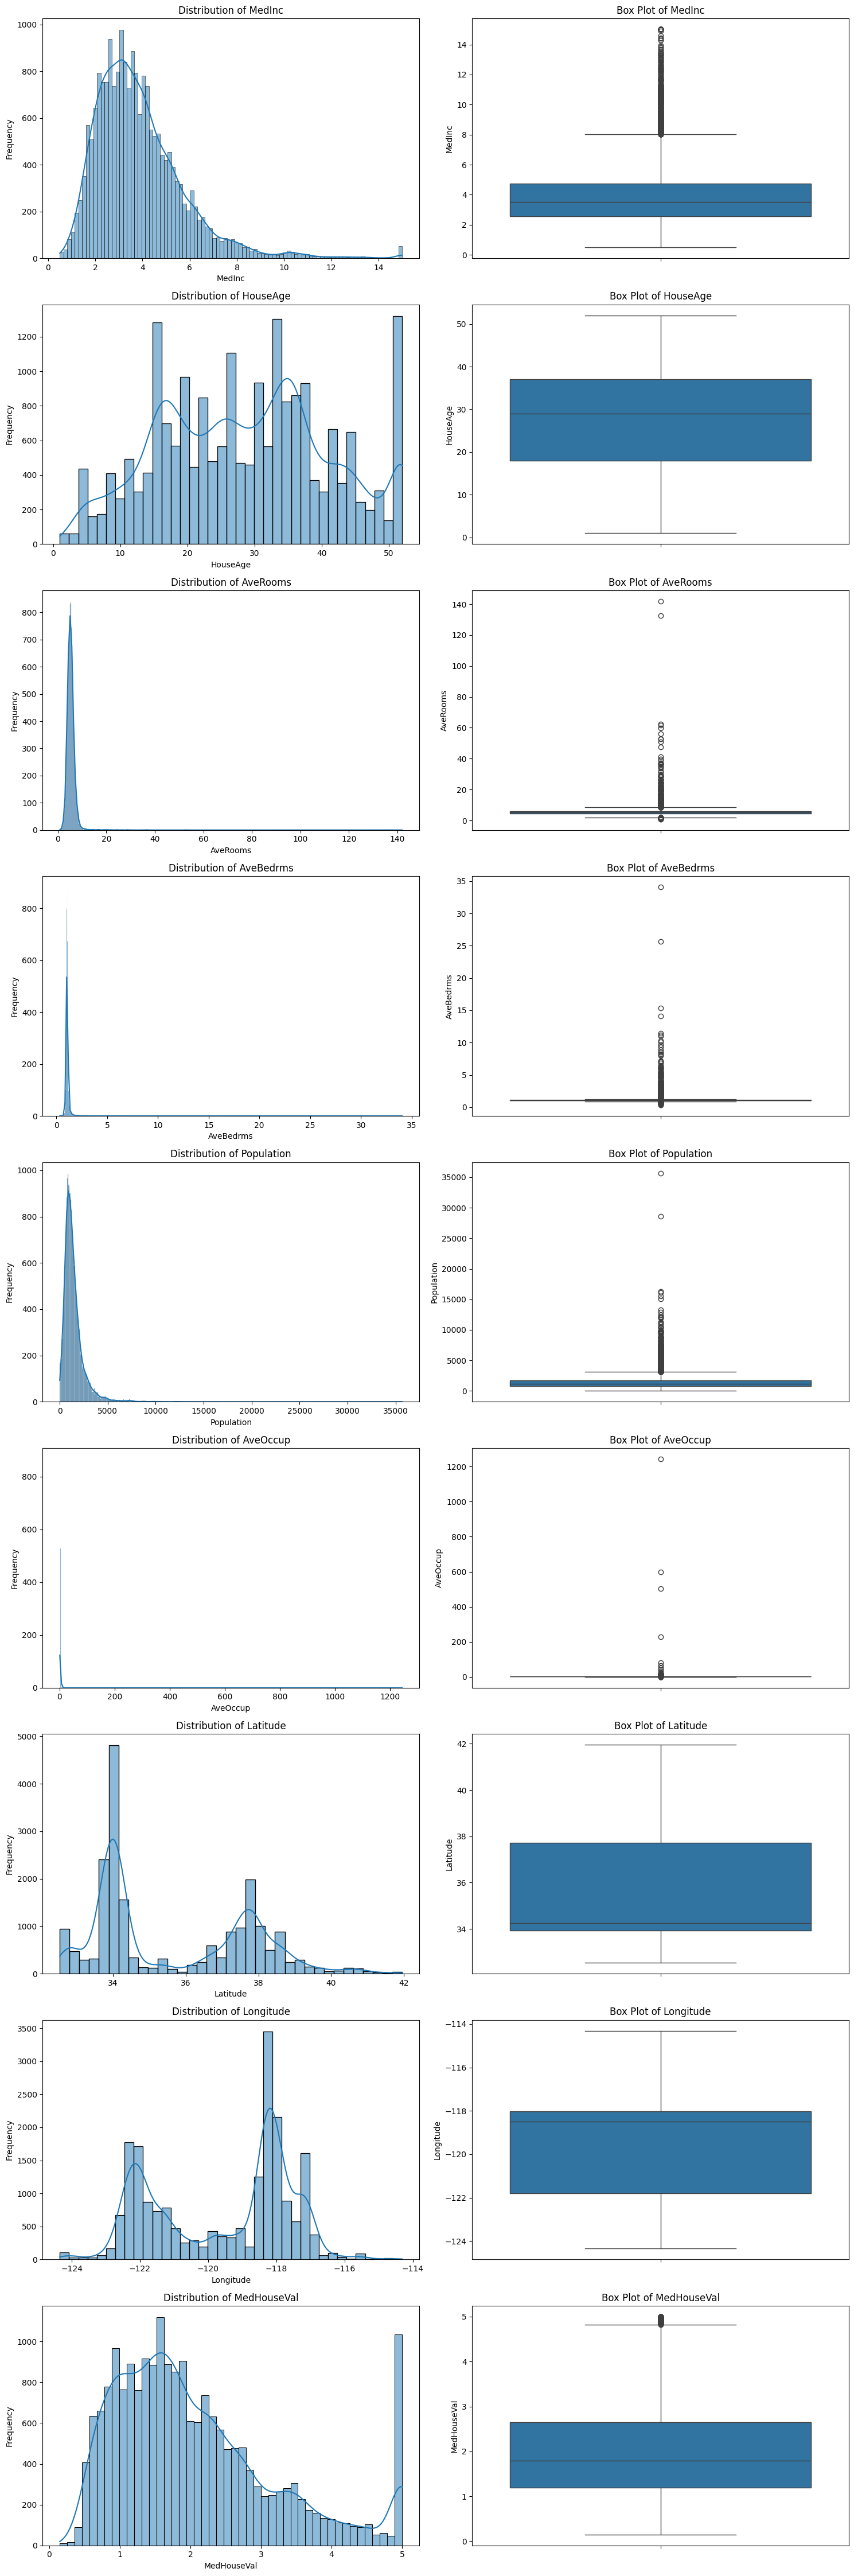

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Identify numerical columns for plotting
numerical_cols = df_california.select_dtypes(include=['number']).columns

# Set up the matplotlib figure and axes
num_numerical_cols = len(numerical_cols)
fig, axes = plt.subplots(num_numerical_cols, 2, figsize=(15, 5 * num_numerical_cols))

# Flatten axes array for easy iteration if there's only one column
if num_numerical_cols == 1:
    axes = axes.reshape(1, -1)

# Loop through each numerical column and create a histplot and boxplot
for i, col in enumerate(numerical_cols):
    # Histplot
    sns.histplot(df_california[col], kde=True, ax=axes[i, 0])
    axes[i, 0].set_title(f'Distribution of {col}')
    axes[i, 0].set_xlabel(col)
    axes[i, 0].set_ylabel('Frequency')

    # Boxplot
    sns.boxplot(y=df_california[col], ax=axes[i, 1])
    axes[i, 1].set_title(f'Box Plot of {col}')
    axes[i, 1].set_ylabel(col)

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.preprocessing import QuantileTransformer, PowerTransformer

# Create copies of the DataFrame for each transformation
df_quantile_uniform = df_california.copy()
df_quantile_gaussian = df_california.copy()
df_yeojohnson = df_california.copy()

numerical_cols = df_california.select_dtypes(include=['number']).columns

# Apply Quantile Transformation (uniform output distribution)
qt_uniform = QuantileTransformer(output_distribution='uniform', random_state=42)
for col in numerical_cols:
    df_quantile_uniform[col] = qt_uniform.fit_transform(df_quantile_uniform[[col]])

# Apply Quantile Transformation (normal/gaussian output distribution)
qt_gaussian = QuantileTransformer(output_distribution='normal', random_state=42)
for col in numerical_cols:
    df_quantile_gaussian[col] = qt_gaussian.fit_transform(df_quantile_gaussian[[col]])

# Apply Yeo-Johnson Transformation
pt_yeojohnson = PowerTransformer(method='yeo-johnson')
for col in numerical_cols:
    # Yeo-Johnson can handle zero and negative values, but fit_transform expects 2D array
    df_yeojohnson[col] = pt_yeojohnson.fit_transform(df_yeojohnson[[col]])

print("Transformations applied successfully!")
print("First 5 rows of Quantile Transformed (Uniform) DataFrame:")
display(df_quantile_uniform.head())
print("\nFirst 5 rows of Quantile Transformed (Gaussian) DataFrame:")
display(df_quantile_gaussian.head())
print("\nFirst 5 rows of Yeo-Johnson Transformed DataFrame:")
display(df_yeojohnson.head())

Transformations applied successfully!
First 5 rows of Quantile Transformed (Uniform) DataFrame:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,0.973039,0.816316,0.901026,0.353754,0.042826,0.328465,0.818318,0.122623,0.939840
1,0.972741,0.311812,0.796525,0.119125,0.883164,0.108232,0.813313,0.126126,0.884226
2,0.948901,1.000000,0.973110,0.641474,0.092798,0.490256,0.811311,0.119119,0.876898
3,0.861964,1.000000,0.696147,0.639453,0.121121,0.323235,0.811311,0.115616,0.862897
4,0.576665,1.000000,0.805008,0.679436,0.123457,0.133102,0.811311,0.115616,0.864203



First 5 rows of Quantile Transformed (Gaussian) DataFrame:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,1.927460,0.901416,1.287419,-0.375206,-1.718788,-0.444156,0.908975,-1.161976,1.553430
1,1.922705,-0.490721,0.829273,-1.179370,1.190954,-1.235984,0.890172,-1.144896,1.196378
2,1.634292,5.199338,1.928605,0.362401,-1.323723,-0.024428,0.882739,-1.179402,1.159620
3,1.089184,5.199338,0.513350,0.356997,-1.169401,-0.458672,0.882739,-1.197193,1.093430
4,0.193368,5.199338,0.859646,0.466123,-1.157879,-1.111848,0.882739,-1.197193,1.099399



First 5 rows of Yeo-Johnson Transformed DataFrame:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,1.903289,0.975968,1.106394,-0.296934,-1.619967,-0.368763,1.089037,-2.414735e-15,1.715878
1,1.897081,-0.568893,0.712367,-0.847336,1.090355,-1.186265,1.082404,-2.414735e-15,1.281389
2,1.604361,1.761010,1.673645,0.162493,-1.139853,0.005053,1.079079,-2.414735e-15,1.247506
3,1.051321,1.761010,0.461045,0.159137,-1.000270,-0.381080,1.079079,-2.414735e-15,1.188835
4,0.205878,1.761010,0.737176,0.228006,-0.985268,-1.040230,1.079079,-2.414735e-15,1.193798


### Histograms for Quantile Transformed (Uniform) DataFrame

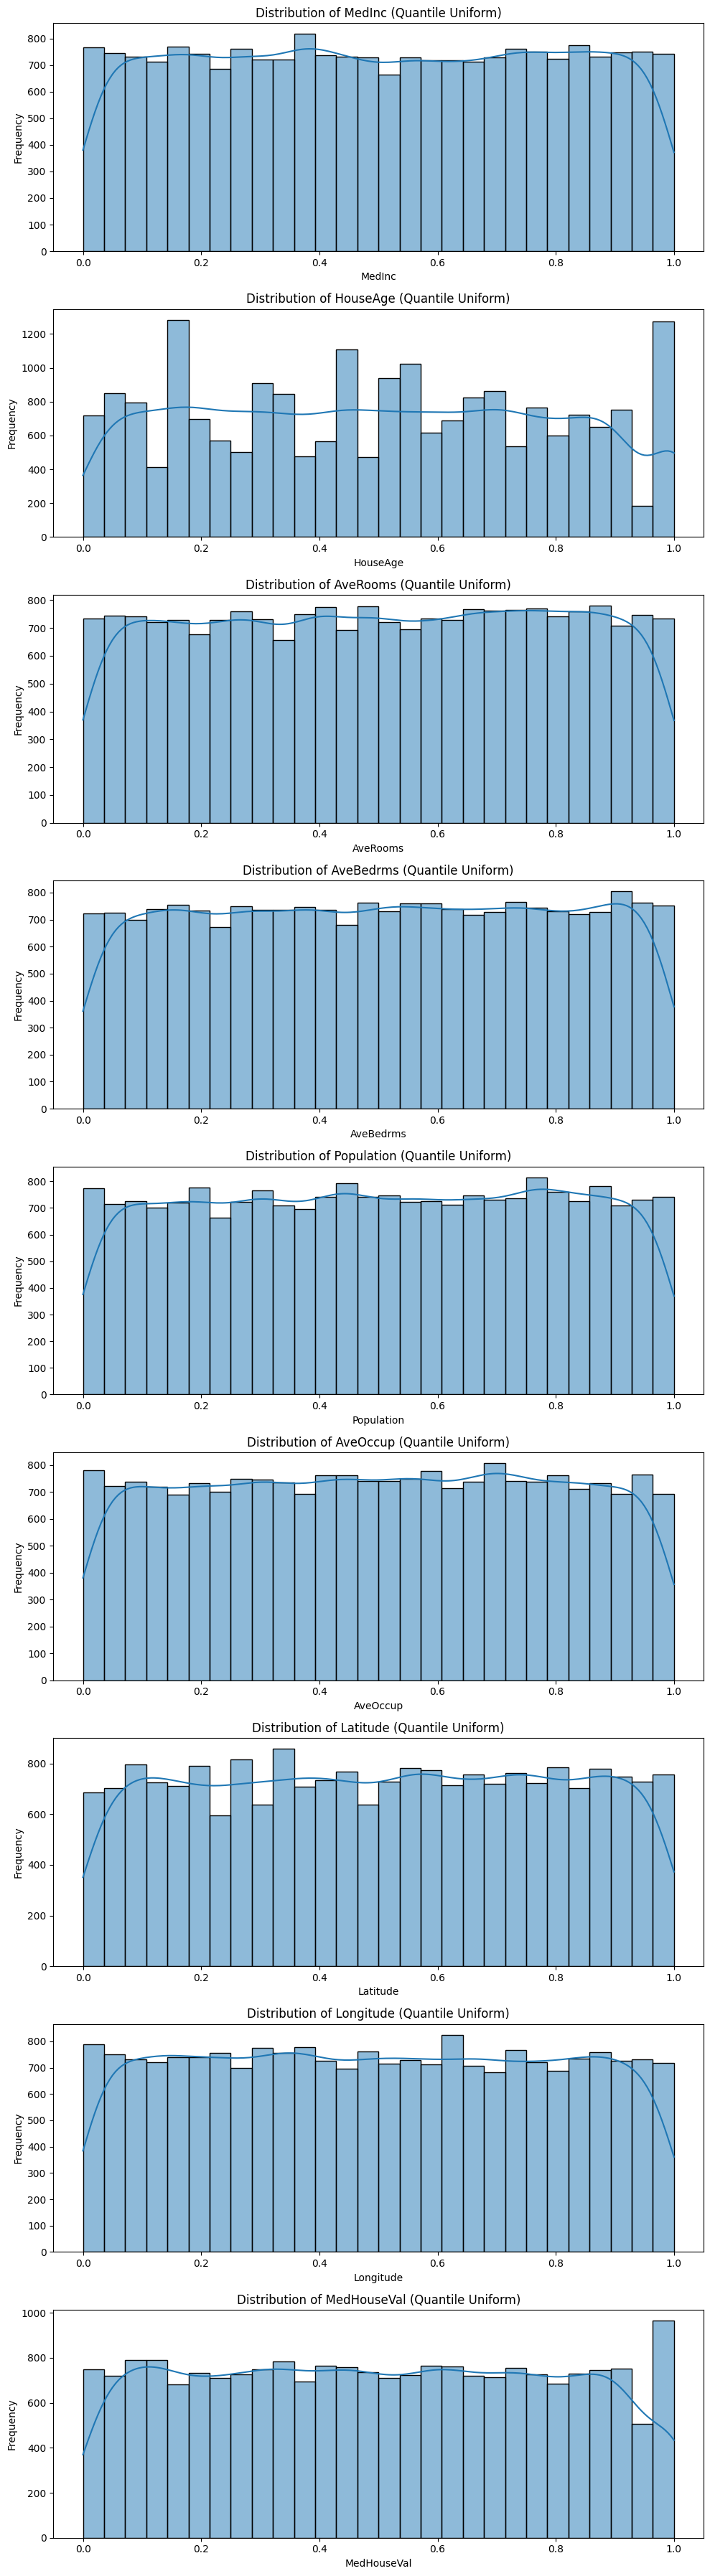

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

numerical_cols = df_quantile_uniform.select_dtypes(include=['number']).columns

# Set up the matplotlib figure and axes for uniform transformed data
num_numerical_cols = len(numerical_cols)
fig_uniform, axes_uniform = plt.subplots(num_numerical_cols, 1, figsize=(10, 4 * num_numerical_cols))

if num_numerical_cols == 1:
    axes_uniform = [axes_uniform] # Ensure axes is iterable

for i, col in enumerate(numerical_cols):
    sns.histplot(df_quantile_uniform[col], kde=True, ax=axes_uniform[i])
    axes_uniform[i].set_title(f'Distribution of {col} (Quantile Uniform)')
    axes_uniform[i].set_xlabel(col)
    axes_uniform[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

<!-- ### Histograms for Quantile Transformed (Gaussian) DataFrame -->

In [ ]:
# import matplotlib.pyplot as plt
# import seaborn as sns

# numerical_cols = df_quantile_gaussian.select_dtypes(include=['number']).columns

# # Set up the matplotlib figure and axes for gaussian transformed data
# num_numerical_cols = len(numerical_cols)
# fig_gaussian, axes_gaussian = plt.subplots(num_numerical_cols, 1, figsize=(10, 4 * num_numerical_cols))

# if num_numerical_cols == 1:
#     axes_gaussian = [axes_gaussian]

# for i, col in enumerate(numerical_cols):
#     sns.histplot(df_quantile_gaussian[col], kde=True, ax=axes_gaussian[i])
#     axes_gaussian[i].set_title(f'Distribution of {col} (Quantile Gaussian)')
#     axes_gaussian[i].set_xlabel(col)
#     axes_gaussian[i].set_ylabel('Frequency')

# plt.tight_layout()
# plt.show()

<!-- ### Histograms for Yeo-Johnson Transformed DataFrame -->

In [ ]:
# import matplotlib.pyplot as plt
# import seaborn as sns

# numerical_cols = df_yeojohnson.select_dtypes(include=['number']).columns

# # Set up the matplotlib figure and axes for Yeo-Johnson transformed data
# num_numerical_cols = len(numerical_cols)
# fig_yeojohnson, axes_yeojohnson = plt.subplots(num_numerical_cols, 1, figsize=(10, 4 * num_numerical_cols))

# if num_numerical_cols == 1:
#     axes_yeojohnson = [axes_yeojohnson]

# for i, col in enumerate(numerical_cols):
#     sns.histplot(df_yeojohnson[col], kde=True, ax=axes_yeojohnson[i])
#     axes_yeojohnson[i].set_title(f'Distribution of {col} (Yeo-Johnson)')
#     axes_yeojohnson[i].set_xlabel(col)
#     axes_yeojohnson[i].set_ylabel('Frequency')

# plt.tight_layout()
# plt.show()

### Box Plots for Quantile Transformed (Uniform) DataFrame

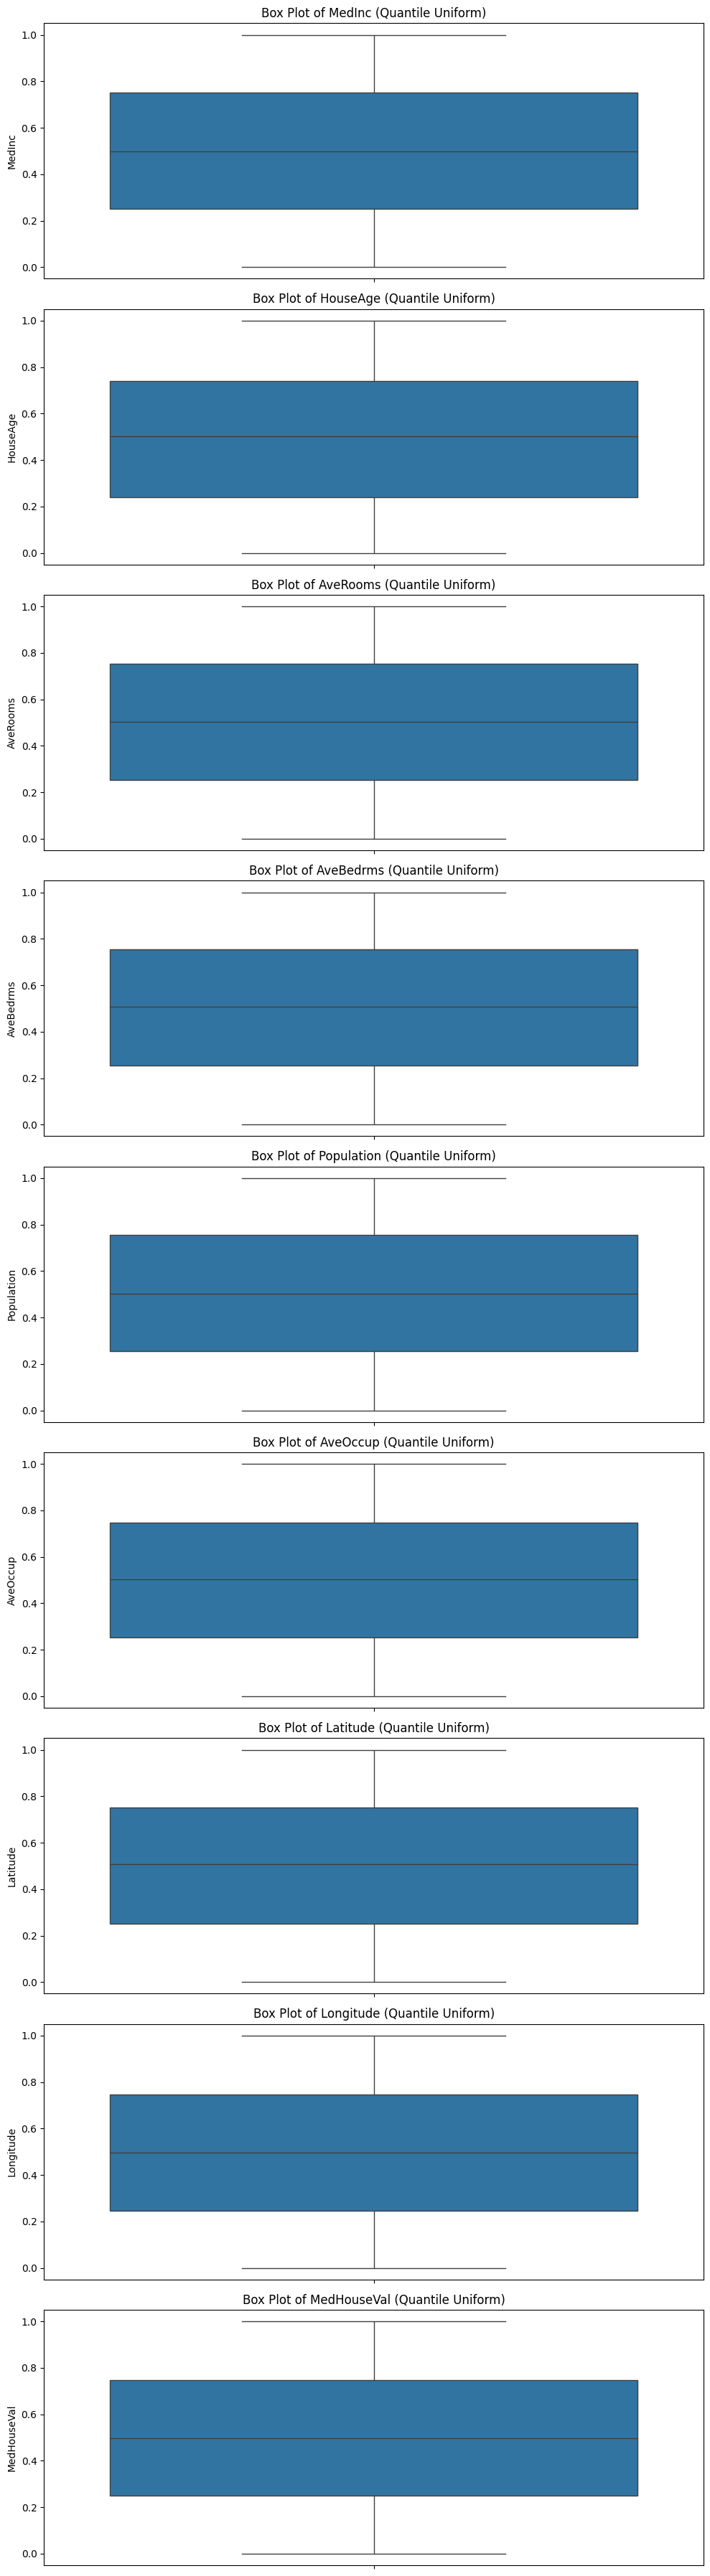

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

numerical_cols = df_quantile_uniform.select_dtypes(include=['number']).columns

# Set up the matplotlib figure and axes for uniform transformed data
num_numerical_cols = len(numerical_cols)
fig_uniform_boxplot, axes_uniform_boxplot = plt.subplots(num_numerical_cols, 1, figsize=(10, 4 * num_numerical_cols))

if num_numerical_cols == 1:
    axes_uniform_boxplot = [axes_uniform_boxplot] # Ensure axes is iterable

for i, col in enumerate(numerical_cols):
    sns.boxplot(y=df_quantile_uniform[col], ax=axes_uniform_boxplot[i])
    axes_uniform_boxplot[i].set_title(f'Box Plot of {col} (Quantile Uniform)')
    axes_uniform_boxplot[i].set_ylabel(col)

plt.tight_layout()
plt.show()

### Imputing Quantile Transformed (Uniform) Data into a New DataFrame

In [ ]:
# Create a copy of the original DataFrame to impute transformed data
df_imputed = df_california.copy()

# Identify numerical columns (assuming they are the same in both dataframes)
numerical_cols = df_california.select_dtypes(include=['number']).columns

# Replace the original numerical columns with the quantile uniform transformed values
for col in numerical_cols:
    df_imputed[col] = df_quantile_uniform[col]

print("Quantile Uniform Transformed data imputed successfully into 'df_imputed'.")
print("First 5 rows of the imputed DataFrame:")
display(df_imputed.head())

Quantile Uniform Transformed data imputed successfully into 'df_imputed'.
First 5 rows of the imputed DataFrame:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,0.973039,0.816316,0.901026,0.353754,0.042826,0.328465,0.818318,0.122623,0.939840
1,0.972741,0.311812,0.796525,0.119125,0.883164,0.108232,0.813313,0.126126,0.884226
2,0.948901,1.000000,0.973110,0.641474,0.092798,0.490256,0.811311,0.119119,0.876898
3,0.861964,1.000000,0.696147,0.639453,0.121121,0.323235,0.811311,0.115616,0.862897
4,0.576665,1.000000,0.805008,0.679436,0.123457,0.133102,0.811311,0.115616,0.864203


### Outlier Detection for Imputed DataFrame (Quantile Uniform Transformed)

In [ ]:
print("Outliers in df_imputed (Quantile Uniform Transformed):")

numerical_cols_imputed = df_imputed.select_dtypes(include=['number']).columns

for col in numerical_cols_imputed:
    Q1 = df_imputed[col].quantile(0.25)
    Q3 = df_imputed[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df_imputed[(df_imputed[col] < lower_bound) | (df_imputed[col] > upper_bound)]

    if not outliers.empty:
        print(f"\nOutliers in '{col}':")
        display(outliers[[col]]) # Display only the outlier column for brevity
    else:
        print(f"\nNo outliers found in '{col}' based on IQR method.")

Outliers in df_imputed (Quantile Uniform Transformed):

No outliers found in 'MedInc' based on IQR method.

No outliers found in 'HouseAge' based on IQR method.

No outliers found in 'AveRooms' based on IQR method.

No outliers found in 'AveBedrms' based on IQR method.

No outliers found in 'Population' based on IQR method.

No outliers found in 'AveOccup' based on IQR method.

No outliers found in 'Latitude' based on IQR method.

No outliers found in 'Longitude' based on IQR method.

No outliers found in 'MedHouseVal' based on IQR method.


In [ ]:
print("Number of outliers in df_imputed (Quantile Uniform Transformed) per column:")

numerical_cols_imputed = df_imputed.select_dtypes(include=['number']).columns

for col in numerical_cols_imputed:
    Q1 = df_imputed[col].quantile(0.25)
    Q3 = df_imputed[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df_imputed[(df_imputed[col] < lower_bound) | (df_imputed[col] > upper_bound)]

    if not outliers.empty:
        print(f"\nNumber of outliers in '{col}': {len(outliers)}")
    else:
        print(f"\nNo outliers found in '{col}' based on IQR method.")

Number of outliers in df_imputed (Quantile Uniform Transformed) per column:

No outliers found in 'MedInc' based on IQR method.

No outliers found in 'HouseAge' based on IQR method.

No outliers found in 'AveRooms' based on IQR method.

No outliers found in 'AveBedrms' based on IQR method.

No outliers found in 'Population' based on IQR method.

No outliers found in 'AveOccup' based on IQR method.

No outliers found in 'Latitude' based on IQR method.

No outliers found in 'Longitude' based on IQR method.

No outliers found in 'MedHouseVal' based on IQR method.


In [ ]:
display(df_imputed)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,0.973039,0.816316,0.901026,0.353754,0.042826,0.328465,0.818318,0.122623,0.939840
1,0.972741,0.311812,0.796525,0.119125,0.883164,0.108232,0.813313,0.126126,0.884226
2,0.948901,1.000000,0.973110,0.641474,0.092798,0.490256,0.811311,0.119119,0.876898
3,0.861964,1.000000,0.696147,0.639453,0.121121,0.323235,0.811311,0.115616,0.862897
4,0.576665,1.000000,0.805008,0.679436,0.123457,0.133102,0.811311,0.115616,0.864203
...,...,...,...,...,...,...,...,...,...
20635,0.043860,0.402402,0.442858,0.846457,0.293794,0.331559,0.970815,0.334334,0.087677
20636,0.247801,0.241241,0.768541,0.958963,0.051051,0.680639,0.971087,0.328328,0.085615
20637,0.064929,0.210210,0.497747,0.815163,0.406406,0.195867,0.969665,0.327327,0.136136
20638,0.092518,0.241241,0.538242,0.903544,0.221221,0.112622,0.969665,0.306306,0.106106


### Splitting Data into Training and Testing Sets

In [ ]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
# Assuming 'MedHouseVal' is the target variable, which represents the median house value.
X = df_imputed.drop('MedHouseVal', axis=1)
y = df_imputed['MedHouseVal']

# Split the data into training and testing sets
# Using a test size of 20% and a random state for reproducibility
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (16512, 8)
X_test shape: (4128, 8)
y_train shape: (16512,)
y_test shape: (4128,)


### Training a Linear Regression Model

In [ ]:
from sklearn.linear_model import LinearRegression

# Initialize the Linear Regression model
linear_model = LinearRegression()

# Train the model on the training data
linear_model.fit(X_train, y_train)

print("Linear Regression model trained successfully!")
print(f"Model Coefficients: {linear_model.coef_}")
print(f"Model Intercept: {linear_model.intercept_}")

Linear Regression model trained successfully!
Model Coefficients: [ 0.7350636   0.11551762 -0.12885331  0.08850261  0.06247089 -0.21761548
 -0.59924564 -0.54867675]
Model Intercept: 0.7458542096576064


### Visualizing Prediction Errors

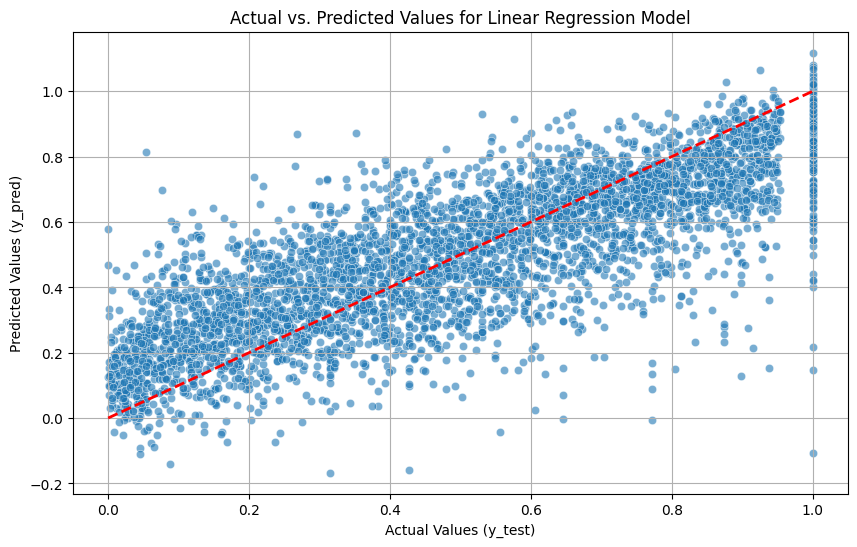

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Make predictions on the test set if not already done
y_pred = linear_model.predict(X_test)

# Create a scatter plot of actual vs predicted values
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # Add a diagonal line for perfect predictions
plt.xlabel('Actual Values (y_test)')
plt.ylabel('Predicted Values (y_pred)')
plt.title('Actual vs. Predicted Values for Linear Regression Model')
plt.grid(True)
plt.show()

### Evaluating Linear Regression Model Performance

In [ ]:
from sklearn.metrics import r2_score

# Make predictions on the training set using Linear Regression
y_train_pred_lr = linear_model.predict(X_train)

# Calculate R-squared for Linear Regression on the training data
r2_lr_train = r2_score(y_train, y_train_pred_lr)

print(f"R-squared for Linear Regression on the training set: {r2_lr_train:.4f}")

R-squared for Linear Regression on the training set: 0.6523


In [ ]:
from sklearn.metrics import mean_squared_error

# Make predictions on the test set
y_pred = linear_model.predict(X_test)

# Calculate Mean Squared Error
mse = mean_squared_error(y_test, y_pred)

print(f"Mean Squared Error (MSE) on the test set: {mse}")

Mean Squared Error (MSE) on the test set: 0.030277602106797384


In [ ]:
from sklearn.metrics import r2_score

# Calculate R-squared for Linear Regression on the test data
r2_lr_test = r2_score(y_test, y_pred)

print(f"R-squared for Linear Regression on the test set: {r2_lr_test:.4f}")

R-squared for Linear Regression on the test set: 0.6396


In [ ]:
import numpy as np
from sklearn.metrics import mean_absolute_error

# Calculate RMSE and MAE for Linear Regression
rmse_lr = np.sqrt(mse)
mae_lr = mean_absolute_error(y_test, y_pred)

print(f"RMSE for Linear Regression on the test set: {rmse_lr:.4f}")
print(f"MAE for Linear Regression on the test set: {mae_lr:.4f}")

RMSE for Linear Regression on the test set: 0.1740
MAE for Linear Regression on the test set: 0.1345


### Training a Random Forest Regressor Model

In [ ]:
from sklearn.ensemble import RandomForestRegressor

# Initialize the Random Forest Regressor model
# Using a random state for reproducibility
random_forest_model = RandomForestRegressor(random_state=42)

# Train the model on the training data
random_forest_model.fit(X_train, y_train)

print("Random Forest Regressor model trained successfully!")

Random Forest Regressor model trained successfully!


### Evaluating Random Forest Regressor Model Performance

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

# Make predictions on the test set using Random Forest
y_pred_rf = random_forest_model.predict(X_test)

# Calculate Mean Squared Error for Random Forest
mse_rf = mean_squared_error(y_test, y_pred_rf)

# Calculate R-squared for Random Forest on the test data
r2_rf_test = r2_score(y_test, y_pred_rf)

print(f"Mean Squared Error (MSE) for Random Forest on the test set: {mse_rf:.4f}")
print(f"R-squared for Random Forest on the test set: {r2_rf_test:.4f}")
print(f"\nMean Squared Error (MSE) for Linear Regression on the test set: {mse:.4f}")
print(f"R-squared for Linear Regression on the test set: {r2_lr_test:.4f}")

if mse_rf < mse:
    print(f"\nThe Random Forest model performed better with a lower MSE than Linear Regression by {mse - mse_rf:.4f}.")
elif mse_rf > mse:
    print(f"\nThe Linear Regression model performed better with a lower MSE than Random Forest by {mse_rf - mse:.4f}.")
else:
    print("\nBoth models achieved the same MSE.")

if r2_rf_test > r2_lr_test:
    print(f"The Random Forest model performed better with a higher R-squared than Linear Regression by {r2_rf_test - r2_lr_test:.4f}.")
elif r2_rf_test < r2_lr_test:
    print(f"The Linear Regression model performed better with a higher R-squared than Random Forest by {r2_lr_test - r2_rf_test:.4f}.")
else:
    print("Both models achieved the same R-squared.")

Mean Squared Error (MSE) for Random Forest on the test set: 0.0144
R-squared for Random Forest on the test set: 0.8289

Mean Squared Error (MSE) for Linear Regression on the test set: 0.0303
R-squared for Linear Regression on the test set: 0.6396

The Random Forest model performed better with a lower MSE than Linear Regression by 0.0159.
The Random Forest model performed better with a higher R-squared than Linear Regression by 0.1893.


In [ ]:
import numpy as np
from sklearn.metrics import mean_absolute_error

# Calculate RMSE and MAE for Untuned Random Forest
rmse_rf = np.sqrt(mse_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)

print(f"RMSE for Untuned Random Forest on the test set: {rmse_rf:.4f}")
print(f"MAE for Untuned Random Forest on the test set: {mae_rf:.4f}")

RMSE for Untuned Random Forest on the test set: 0.1199
MAE for Untuned Random Forest on the test set: 0.0835


In [ ]:
print("Other regression algorithms to consider:")
print("1. Gradient Boosting Regressors (e.g., XGBoost, LightGBM, CatBoost)")
print("2. Support Vector Regressor (SVR)")
print("3. K-Nearest Neighbors Regressor (KNR)")
print("4. Neural Networks (e.g., Multi-layer Perceptron Regressor)")

Other regression algorithms to consider:
1. Gradient Boosting Regressors (e.g., XGBoost, LightGBM, CatBoost)
2. Support Vector Regressor (SVR)
3. K-Nearest Neighbors Regressor (KNR)
4. Neural Networks (e.g., Multi-layer Perceptron Regressor)


### Training and Evaluating XGBoost Regressor

In [ ]:
!pip install xgboost

In [ ]:
import xgboost as xgb
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np

# Initialize XGBoost Regressor
xgb_model = xgb.XGBRegressor(random_state=42)

print("Training XGBoost Regressor...")
# Train the model
xgb_model.fit(X_train, y_train)
print("XGBoost Regressor trained successfully!")

# Make predictions on the test set
y_pred_xgb = xgb_model.predict(X_test)

# Calculate metrics
mse_xgb = mean_squared_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mse_xgb)
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

print(f"\nXGBoost Regressor Performance on Test Set:")
print(f"Mean Squared Error (MSE): {mse_xgb:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse_xgb:.4f}")
print(f"Mean Absolute Error (MAE): {mae_xgb:.4f}")
print(f"R-squared: {r2_xgb:.4f}")

Training XGBoost Regressor...
XGBoost Regressor trained successfully!

XGBoost Regressor Performance on Test Set:
Mean Squared Error (MSE): 0.0126
Root Mean Squared Error (RMSE): 0.1121
Mean Absolute Error (MAE): 0.0782
R-squared: 0.8506


### Hyperparameter Tuning for Xgboost

In [ ]:
from sklearn.model_selection import GridSearchCV
import xgboost as xgb
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np

# Define the parameter grid for XGBoost
param_grid_xgb = {
    'n_estimators': [100, 200, 300],  # Number of boosting rounds
    'max_depth': [3, 5, 7],           # Maximum depth of a tree
    'learning_rate': [0.01, 0.1, 0.2], # Step size shrinkage to prevent overfitting
    'subsample': [0.7, 0.9],          # Subsample ratio of the training instance
    'colsample_bytree': [0.7, 0.9]    # Subsample ratio of columns when constructing each tree
}

# Initialize the XGBoost Regressor model
xgb_model_grid = xgb.XGBRegressor(random_state=42)

# Initialize GridSearchCV
# Using a smaller cv (e.g., 3) for quicker execution in demonstration
grid_search_xgb = GridSearchCV(estimator=xgb_model_grid, param_grid=param_grid_xgb,
                               cv=3, n_jobs=-1, verbose=2, scoring='neg_mean_squared_error')

print("Starting Grid Search for XGBoost hyperparameters...")
# Fit GridSearchCV to the training data
grid_search_xgb.fit(X_train, y_train)

print("Grid Search completed!")
print(f"Best hyperparameters found for XGBoost: {grid_search_xgb.best_params_}")

# Get the best model from GridSearchCV
best_xgb_model = grid_search_xgb.best_estimator_

# Make predictions on the test set using the best XGBoost model
y_pred_tuned_xgb = best_xgb_model.predict(X_test)

# Calculate metrics for the tuned XGBoost model
mse_tuned_xgb = mean_squared_error(y_test, y_pred_tuned_xgb)
rmse_tuned_xgb = np.sqrt(mse_tuned_xgb)
mae_tuned_xgb = mean_absolute_error(y_test, y_pred_tuned_xgb)
r2_tuned_xgb = r2_score(y_test, y_pred_tuned_xgb)

print(f"\nTuned XGBoost Regressor Performance on Test Set:")
print(f"Mean Squared Error (MSE): {mse_tuned_xgb:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse_tuned_xgb:.4f}")
print(f"Mean Absolute Error (MAE): {mae_tuned_xgb:.4f}")
print(f"R-squared: {r2_tuned_xgb:.4f}")

print(f"\nComparison with untuned XGBoost:")
print(f"Untuned XGBoost MSE: {mse_xgb:.4f}")
print(f"Untuned XGBoost R-squared: {r2_xgb:.4f}")

if mse_tuned_xgb < mse_xgb:
    print(f"The tuned XGBoost model performed better with a lower MSE than the untuned model by {mse_xgb - mse_tuned_xgb:.4f}.")
elif mse_tuned_xgb > mse_xgb:
    print(f"The untuned XGBoost model performed better with a lower MSE than the tuned model by {mse_tuned_xgb - mse_xgb:.4f}.")
else:
    print("Both tuned and untuned XGBoost models achieved the same MSE.")

if r2_tuned_xgb > r2_xgb:
    print(f"The tuned XGBoost model performed better with a higher R-squared than the untuned model by {r2_tuned_xgb - r2_xgb:.4f}.")
elif r2_tuned_xgb < r2_xgb:
    print(f"The untuned XGBoost model performed better with a higher R-squared than the tuned model by {r2_xgb - r2_tuned_xgb:.4f}.")
else:
    print("Both tuned and untuned XGBoost models achieved the same R-squared.")

Starting Grid Search for XGBoost hyperparameters...
Fitting 3 folds for each of 108 candidates, totalling 324 fits
Grid Search completed!
Best hyperparameters found for XGBoost: {'colsample_bytree': 0.7, 'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 300, 'subsample': 0.9}

Tuned XGBoost Regressor Performance on Test Set:
Mean Squared Error (MSE): 0.0112
Root Mean Squared Error (RMSE): 0.1057
Mean Absolute Error (MAE): 0.0730
R-squared: 0.8670

Comparison with untuned XGBoost:
Untuned XGBoost MSE: 0.0126
Untuned XGBoost R-squared: 0.8506
The tuned XGBoost model performed better with a lower MSE than the untuned model by 0.0014.
The tuned XGBoost model performed better with a higher R-squared than the untuned model by 0.0164.


### Training and Evaluating LightGBM Regressor

In [ ]:
!pip install lightgbm

In [ ]:
import lightgbm as lgb
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np

# Initialize LightGBM Regressor
lgbm_model = lgb.LGBMRegressor(random_state=42)

print("Training LightGBM Regressor...")
# Train the model
lgbm_model.fit(X_train, y_train)
print("LightGBM Regressor trained successfully!")

# Make predictions on the test set
y_pred_lgbm = lgbm_model.predict(X_test)

# Calculate metrics
mse_lgbm = mean_squared_error(y_test, y_pred_lgbm)
rmse_lgbm = np.sqrt(mse_lgbm)
mae_lgbm = mean_absolute_error(y_test, y_pred_lgbm)
r2_lgbm = r2_score(y_test, y_pred_lgbm)

print(f"\nLightGBM Regressor Performance on Test Set:")
print(f"Mean Squared Error (MSE): {mse_lgbm:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse_lgbm:.4f}")
print(f"Mean Absolute Error (MAE): {mae_lgbm:.4f}")
print(f"R-squared: {r2_lgbm:.4f}")

Training LightGBM Regressor...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.006358 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1837
[LightGBM] [Info] Number of data points in the train set: 16512, number of used features: 8
[LightGBM] [Info] Start training from score 0.500376
LightGBM Regressor trained successfully!

LightGBM Regressor Performance on Test Set:
Mean Squared Error (MSE): 0.0126
Root Mean Squared Error (RMSE): 0.1121
Mean Absolute Error (MAE): 0.0790
R-squared: 0.8504


### Training and Evaluating CatBoost Regressor

In [ ]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.5 MB/s eta 0:00:00


In [ ]:
import catboost as cb
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np

# Initialize CatBoost Regressor
# verbose=0 to suppress training output for cleaner notebook
catboost_model = cb.CatBoostRegressor(random_state=42, verbose=0)

print("Training CatBoost Regressor...")
# Train the model
catboost_model.fit(X_train, y_train)
print("CatBoost Regressor trained successfully!")

# Make predictions on the test set
y_pred_catboost = catboost_model.predict(X_test)

# Calculate metrics
mse_catboost = mean_squared_error(y_test, y_pred_catboost)
rmse_catboost = np.sqrt(mse_catboost)
mae_catboost = mean_absolute_error(y_test, y_pred_catboost)
r2_catboost = r2_score(y_test, y_pred_catboost)

print(f"\nCatBoost Regressor Performance on Test Set:")
print(f"Mean Squared Error (MSE): {mse_catboost:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse_catboost:.4f}")
print(f"Mean Absolute Error (MAE): {mae_catboost:.4f}")
print(f"R-squared: {r2_catboost:.4f}")

Training CatBoost Regressor...
CatBoost Regressor trained successfully!

CatBoost Regressor Performance on Test Set:
Mean Squared Error (MSE): 0.0113
Root Mean Squared Error (RMSE): 0.1063
Mean Absolute Error (MAE): 0.0738
R-squared: 0.8654


### Training and Evaluating BY MLP

In [ ]:
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np

# Initialize MLP Regressor
# Using a solver like 'adam' and setting max_iter to a reasonable number
# Setting random_state for reproducibility
mlp_model = MLPRegressor(solver='adam', alpha=1e-5, hidden_layer_sizes=(100, 50), random_state=42, max_iter=500)

print("Training MLP Regressor...")
# Train the model
mlp_model.fit(X_train, y_train)
print("MLP Regressor trained successfully!")

# Make predictions on the test set
y_pred_mlp = mlp_model.predict(X_test)

# Calculate metrics
mse_mlp = mean_squared_error(y_test, y_pred_mlp)
rmse_mlp = np.sqrt(mse_mlp)
mae_mlp = mean_absolute_error(y_test, y_pred_mlp)
r2_mlp = r2_score(y_test, y_pred_mlp)

print(f"\nMLP Regressor Performance on Test Set:")
print(f"Mean Squared Error (MSE): {mse_mlp:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse_mlp:.4f}")
print(f"Mean Absolute Error (MAE): {mae_mlp:.4f}")
print(f"R-squared: {r2_mlp:.4f}")

Training MLP Regressor...
MLP Regressor trained successfully!

MLP Regressor Performance on Test Set:
Mean Squared Error (MSE): 0.0162
Root Mean Squared Error (RMSE): 0.1274
Mean Absolute Error (MAE): 0.0918
R-squared: 0.8068


### Comprehensive Model Performance Comparison (Updated)

In [ ]:
import pandas as pd

# Create a dictionary to store all model performances
performance_data = {
    'Model': [
        'Linear Regression',
        'Random Forest (Untuned)',
        'XGBoost (Untuned)',
        'XGBoost (Tuned)',
        'LightGBM',
        'CatBoost',
        'MLP Regressor'
    ],
    'R-squared': [
        r2_lr_test, r2_rf_test, r2_xgb, r2_tuned_xgb, r2_lgbm, r2_catboost, r2_mlp
    ],
    'MSE': [
        mse, mse_rf, mse_xgb, mse_tuned_xgb, mse_lgbm, mse_catboost, mse_mlp
    ],
    'RMSE': [
        rmse_lr, rmse_rf, rmse_xgb, rmse_tuned_xgb, rmse_lgbm, rmse_catboost, rmse_mlp
    ],
    'MAE': [
        mae_lr, mae_rf, mae_xgb, mae_tuned_xgb, mae_lgbm, mae_catboost, mae_mlp
    ]
}

# Create a DataFrame for easy comparison
performance_df = pd.DataFrame(performance_data)

print("Model Performance Comparison on Test Set:")
display(performance_df.sort_values(by='R-squared', ascending=False))

Model Performance Comparison on Test Set:


,Model,R-squared,MSE,RMSE,MAE
3,XGBoost (Tuned),0.866968,0.011177,0.105721,0.072987
5,CatBoost,0.865427,0.011306,0.106332,0.073807
2,XGBoost (Untuned),0.850559,0.012556,0.112052,0.078155
4,LightGBM,0.850429,0.012567,0.112101,0.079004
1,Random Forest (Untuned),0.828913,0.014374,0.119893,0.083517
6,MLP Regressor,0.806835,0.016229,0.127394,0.091803
0,Linear Regression,0.639627,0.030278,0.174005,0.134520


In [ ]:
### Performing Feature Engineering with xgboost

In [ ]:
import numpy as np

# Create copies of X_train and X_test for feature engineering
X_train_fe = X_train.copy()
X_test_fe = X_test.copy()

# --- Feature Engineering ---

# 1. Rooms per person (AveRooms / AveOccup)
X_train_fe['Rooms_per_Person'] = X_train_fe['AveRooms'] / X_train_fe['AveOccup']
X_test_fe['Rooms_per_Person'] = X_test_fe['AveRooms'] / X_test_fe['AveOccup']

# 2. Bedrooms per room (AveBedrms / AveRooms)
X_train_fe['Bedrms_per_Room'] = X_train_fe['AveBedrms'] / X_train_fe['AveRooms']
X_test_fe['Bedrms_per_Room'] = X_test_fe['AveBedrms'] / X_test_fe['AveRooms']

# Handle potential division by zero if AveRooms is 0 (though unlikely in this dataset after quantile transform)
X_train_fe.replace([np.inf, -np.inf], np.nan, inplace=True)
X_test_fe.replace([np.inf, -np.inf], np.nan, inplace=True)
# Simple imputation for NaN values (e.g., fill with median of the column) if any were created
for col in ['Rooms_per_Person', 'Bedrms_per_Room']:
    if X_train_fe[col].isnull().any():
        median_val = X_train_fe[col].median()
        X_train_fe[col].fillna(median_val, inplace=True)
        X_test_fe[col].fillna(median_val, inplace=True)

# 3. Interaction between Latitude and Longitude (simple product)
X_train_fe['Lat_Lon_Interact'] = X_train_fe['Latitude'] * X_train_fe['Longitude']
X_test_fe['Lat_Lon_Interact'] = X_test_fe['Latitude'] * X_test_fe['Longitude']

# --- Retrain Tuned XGBoost with Engineered Features ---

print("Retraining Tuned XGBoost Regressor with engineered features...")
# The best_xgb_model was obtained from the GridSearchCV in the previous step
# We will use the same hyperparameters but retrain it on the new data
best_xgb_model_fe = grid_search_xgb.best_estimator_ # Re-initialize to ensure a fresh fit
best_xgb_model_fe.fit(X_train_fe, y_train)
print("Tuned XGBoost Regressor retrained successfully with engineered features!")

# --- Evaluate Performance ---

from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Make predictions on the test set using the retrained model
y_pred_tuned_xgb_fe = best_xgb_model_fe.predict(X_test_fe)

# Calculate metrics for the tuned XGBoost model with engineered features
mse_tuned_xgb_fe = mean_squared_error(y_test, y_pred_tuned_xgb_fe)
rmse_tuned_xgb_fe = np.sqrt(mse_tuned_xgb_fe)
mae_tuned_xgb_fe = mean_absolute_error(y_test, y_pred_tuned_xgb_fe)
r2_tuned_xgb_fe = r2_score(y_test, y_pred_tuned_xgb_fe)

print(f"\nPerformance of Tuned XGBoost Regressor with Engineered Features on Test Set:")
print(f"Mean Squared Error (MSE): {mse_tuned_xgb_fe:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse_tuned_xgb_fe:.4f}")
print(f"Mean Absolute Error (MAE): {mae_tuned_xgb_fe:.4f}")
print(f"R-squared: {r2_tuned_xgb_fe:.4f}")

print(f"\nComparison with Tuned XGBoost (without Feature Engineering):")
print(f"Original Tuned XGBoost MSE: {mse_tuned_xgb:.4f}")
print(f"Original Tuned XGBoost R-squared: {r2_tuned_xgb:.4f}")

if mse_tuned_xgb_fe < mse_tuned_xgb:
    print(f"The Tuned XGBoost model with Feature Engineering performed better with a lower MSE by {mse_tuned_xgb - mse_tuned_xgb_fe:.4f}.")
elif mse_tuned_xgb_fe > mse_tuned_xgb:
    print(f"The Tuned XGBoost model without Feature Engineering performed better with a lower MSE by {mse_tuned_xgb_fe - mse_tuned_xgb:.4f}.")
else:
    print("Both Tuned XGBoost models achieved the same MSE.")

if r2_tuned_xgb_fe > r2_tuned_xgb:
    print(f"The Tuned XGBoost model with Feature Engineering performed better with a higher R-squared by {r2_tuned_xgb_fe - r2_tuned_xgb:.4f}.")
elif r2_tuned_xgb_fe < r2_tuned_xgb:
    print(f"The Tuned XGBoost model without Feature Engineering performed better with a higher R-squared by {r2_tuned_xgb - r2_tuned_xgb_fe:.4f}.")
else:
    print("Both Tuned XGBoost models achieved the same R-squared.")

Retraining Tuned XGBoost Regressor with engineered features...


/tmp/ipykernel_4977/207951260.py:24: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X_train_fe[col].fillna(median_val, inplace=True)
/tmp/ipykernel_4977/207951260.py:25: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try 

Tuned XGBoost Regressor retrained successfully with engineered features!

Performance of Tuned XGBoost Regressor with Engineered Features on Test Set:
Mean Squared Error (MSE): 0.0105
Root Mean Squared Error (RMSE): 0.1024
Mean Absolute Error (MAE): 0.0704
R-squared: 0.8753

Comparison with Tuned XGBoost (without Feature Engineering):
Original Tuned XGBoost MSE: 0.0112
Original Tuned XGBoost R-squared: 0.8670
The Tuned XGBoost model with Feature Engineering performed better with a lower MSE by 0.0007.
The Tuned XGBoost model with Feature Engineering performed better with a higher R-squared by 0.0083.


### Hyperparameter Tuning for XGBoost with Feature Engineering, including L1/L2 Regularization

In [ ]:
from sklearn.model_selection import GridSearchCV
import xgboost as xgb
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np

# Define an extended parameter grid for XGBoost including L1 and L2 regularization
# We'll start with the best parameters found previously and add regularization terms
param_grid_xgb_l1_l2 = {
    'n_estimators': [300],  # From previous best_params_ (or narrow range around it)
    'max_depth': [7],         # From previous best_params_
    'learning_rate': [0.1],  # From previous best_params_
    'subsample': [0.9],       # From previous best_params_
    'colsample_bytree': [0.7],# From previous best_params_
    'reg_alpha': [0, 0.001, 0.01, 0.1], # L1 regularization term
    'reg_lambda': [0, 0.001, 0.01, 0.1]  # L2 regularization term
}

# Initialize the XGBoost Regressor model
xgb_model_grid_l1_l2 = xgb.XGBRegressor(random_state=42)

# Initialize GridSearchCV
# Using a smaller cv (e.g., 3) for quicker execution in demonstration
grid_search_xgb_l1_l2 = GridSearchCV(estimator=xgb_model_grid_l1_l2, param_grid=param_grid_xgb_l1_l2,
                                   cv=3, n_jobs=-1, verbose=2, scoring='neg_mean_squared_error')

print("Starting Grid Search for XGBoost hyperparameters with L1/L2 regularization...")
# Fit GridSearchCV to the training data with engineered features
grid_search_xgb_l1_l2.fit(X_train_fe, y_train)

print("Grid Search with L1/L2 regularization completed!")
print(f"Best hyperparameters found for XGBoost with L1/L2: {grid_search_xgb_l1_l2.best_params_}")

# Get the best model from GridSearchCV
best_xgb_model_fe_l1_l2 = grid_search_xgb_l1_l2.best_estimator_

# Make predictions on the test set using the best XGBoost model
y_pred_xgb_fe_l1_l2 = best_xgb_model_fe_l1_l2.predict(X_test_fe)

# Calculate metrics for the L1/L2 tuned XGBoost model
mse_xgb_fe_l1_l2 = mean_squared_error(y_test, y_pred_xgb_fe_l1_l2)
rmse_xgb_fe_l1_l2 = np.sqrt(mse_xgb_fe_l1_l2)
mae_xgb_fe_l1_l2 = mean_absolute_error(y_test, y_pred_xgb_fe_l1_l2)
r2_xgb_fe_l1_l2 = r2_score(y_test, y_pred_xgb_fe_l1_l2)

print(f"\nTuned XGBoost Regressor with Feature Engineering and L1/L2 (Test Set):")
print(f"Mean Squared Error (MSE): {mse_xgb_fe_l1_l2:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse_xgb_fe_l1_l2:.4f}")
print(f"Mean Absolute Error (MAE): {mae_xgb_fe_l1_l2:.4f}")
print(f"R-squared: {r2_xgb_fe_l1_l2:.4f}")

print(f"\nComparison with Tuned XGBoost (with Feature Engineering, without L1/L2 tuning):")
print(f"Original Tuned XGBoost FE MSE: {mse_tuned_xgb_fe:.4f}")
print(f"Original Tuned XGBoost FE R-squared: {r2_tuned_xgb_fe:.4f}")

if mse_xgb_fe_l1_l2 < mse_tuned_xgb_fe:
    print(f"The Tuned XGBoost FE model with L1/L2 performed better with a lower MSE by {mse_tuned_xgb_fe - mse_xgb_fe_l1_l2:.4f}.")
elif mse_xgb_fe_l1_l2 > mse_tuned_xgb_fe:
    print(f"The Tuned XGBoost FE model without L1/L2 performed better with a lower MSE by {mse_xgb_fe_l1_l2 - mse_tuned_xgb_fe:.4f}.")
else:
    print("Both Tuned XGBoost FE models achieved the same MSE.")

if r2_xgb_fe_l1_l2 > r2_tuned_xgb_fe:
    print(f"The Tuned XGBoost FE model with L1/L2 performed better with a higher R-squared by {r2_xgb_fe_l1_l2 - r2_tuned_xgb_fe:.4f}.")
elif r2_xgb_fe_l1_l2 < r2_tuned_xgb_fe:
    print(f"The Tuned XGBoost FE model without L1/L2 performed better with a higher R-squared by {r2_tuned_xgb_fe - r2_xgb_fe_l1_l2:.4f}.")
else:
    print("Both Tuned XGBoost FE models achieved the same R-squared.")

Starting Grid Search for XGBoost hyperparameters with L1/L2 regularization...
Fitting 3 folds for each of 16 candidates, totalling 48 fits
Grid Search with L1/L2 regularization completed!
Best hyperparameters found for XGBoost with L1/L2: {'colsample_bytree': 0.7, 'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 300, 'reg_alpha': 0.1, 'reg_lambda': 0.001, 'subsample': 0.9}

Tuned XGBoost Regressor with Feature Engineering and L1/L2 (Test Set):
Mean Squared Error (MSE): 0.0104
Root Mean Squared Error (RMSE): 0.1021
Mean Absolute Error (MAE): 0.0703
R-squared: 0.8760

Comparison with Tuned XGBoost (with Feature Engineering, without L1/L2 tuning):
Original Tuned XGBoost FE MSE: 0.0105
Original Tuned XGBoost FE R-squared: 0.8753
The Tuned XGBoost FE model with L1/L2 performed better with a lower MSE by 0.0001.
The Tuned XGBoost FE model with L1/L2 performed better with a higher R-squared by 0.0008.


In [ ]:
from sklearn.model_selection import KFold, cross_val_score
import numpy as np

# Define the number of splits for K-Fold Cross-Validation
n_splits = 5  # Common choice, can be adjusted
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

print(f"Performing {n_splits}-Fold Cross-Validation on the Tuned XGBoost model with Feature Engineering and L1/L2 regularization...")

# Evaluate R-squared using cross_val_score
r2_scores_cv = cross_val_score(best_xgb_model_fe_l1_l2, X_train_fe, y_train, cv=kf, scoring='r2', n_jobs=-1)
print(f"Average R-squared (CV): {np.mean(r2_scores_cv):.4f} (+/- {np.std(r2_scores_cv):.4f})")

# Evaluate negative Mean Squared Error using cross_val_score
mse_scores_cv = -cross_val_score(best_xgb_model_fe_l1_l2, X_train_fe, y_train, cv=kf, scoring='neg_mean_squared_error', n_jobs=-1)
print(f"Average MSE (CV): {np.mean(mse_scores_cv):.4f} (+/- {np.std(mse_scores_cv):.4f})")

print(f"\nRMSE (CV): {np.sqrt(np.mean(mse_scores_cv)):.4f}")

Performing 5-Fold Cross-Validation on the Tuned XGBoost model with Feature Engineering and L1/L2 regularization...
Average R-squared (CV): 0.8670 (+/- 0.0052)
Average MSE (CV): 0.0113 (+/- 0.0005)

RMSE (CV): 0.1061


### Residual Analysis for Tuned XGBoost (with Feature Engineering and L1/L2)

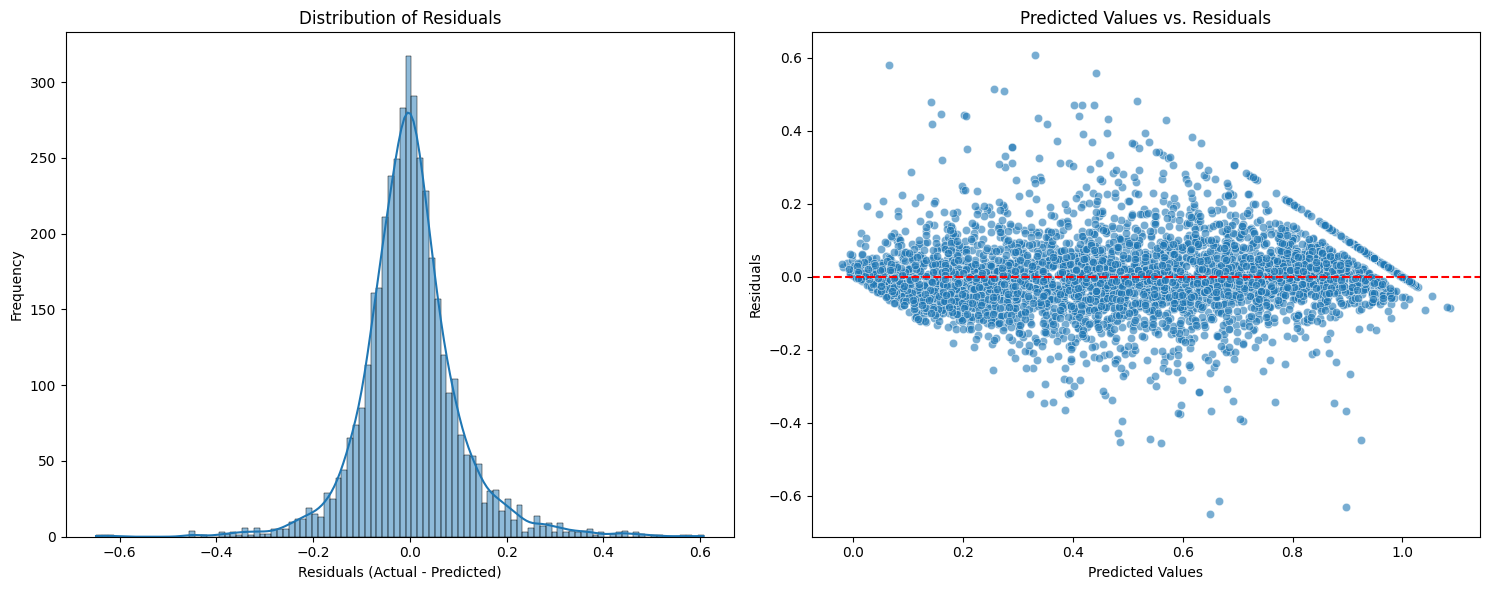

Mean of Residuals: 0.0005
Standard Deviation of Residuals: 0.1020


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Calculate residuals (Actual - Predicted)
residuals = y_test - y_pred_xgb_fe_l1_l2

plt.figure(figsize=(15, 6))

# Subplot 1: Histogram of Residuals
plt.subplot(1, 2, 1)
sns.histplot(residuals, kde=True)
plt.title('Distribution of Residuals')
plt.xlabel('Residuals (Actual - Predicted)')
plt.ylabel('Frequency')

# Subplot 2: Scatter plot of Predicted vs. Residuals
plt.subplot(1, 2, 2)
sns.scatterplot(x=y_pred_xgb_fe_l1_l2, y=residuals, alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--') # Add a horizontal line at 0
plt.title('Predicted Values vs. Residuals')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')

plt.tight_layout()
plt.show()

print(f"Mean of Residuals: {np.mean(residuals):.4f}")
print(f"Standard Deviation of Residuals: {np.std(residuals):.4f}")

### Feature Importance Analysis for Tuned XGBoost (with Feature Engineering and L1/L2)

In [ ]:
import pandas as pd

# Get feature importances from the best_xgb_model_fe_l1_l2
feature_importances = best_xgb_model_fe_l1_l2.feature_importances_

# Get feature names from X_train_fe
feature_names = X_train_fe.columns

# Create a DataFrame for better visualization
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
})

# Sort the DataFrame by importance in descending order
importance_df = importance_df.sort_values(by='Importance', ascending=False)

print("Feature Importances in Tuned XGBoost Model (with Feature Engineering and L1/L2):")
display(importance_df)

Feature Importances in Tuned XGBoost Model (with Feature Engineering and L1/L2):


,Feature,Importance
0,MedInc,0.235005
7,Longitude,0.176732
6,Latitude,0.135164
10,Lat_Lon_Interact,0.109294
8,Rooms_per_Person,0.091632
5,AveOccup,0.072840
2,AveRooms,0.066480
9,Bedrms_per_Room,0.049824
1,HouseAge,0.029843
3,AveBedrms,0.016940


### Advanced Hyperparameter Tuning for XGBoost (with Feature Engineering and L1/L2)

In [1]:
from sklearn.model_selection import GridSearchCV
import xgboost as xgb
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np

# Define an expanded parameter grid for XGBoost
# Building upon the previously best parameters and exploring a wider range
param_grid_xgb_advanced = {
    'n_estimators': [200, 300, 400, 500], # Expanded around 300
    'max_depth': [5, 7, 9],           # Expanded around 7
    'learning_rate': [0.05, 0.1, 0.15], # Expanded around 0.1
    'subsample': [0.7, 0.8, 0.9],         # Expanded around 0.9
    'colsample_bytree': [0.6, 0.7, 0.8], # Expanded around 0.7
    'reg_alpha': [0, 0.01, 0.1, 0.5],     # Expanded around 0.1
    'reg_lambda': [0, 0.001, 0.01, 0.1],  # Expanded around 0.001
    'gamma': [0, 0.1, 0.2],               # Added new parameter
    'min_child_weight': [1, 5, 10]        # Added new parameter
}

# Initialize the XGBoost Regressor model
xgb_model_grid_advanced = xgb.XGBRegressor(random_state=42)

# Initialize GridSearchCV with increased cv folds for more robust evaluation
grid_search_xgb_advanced = GridSearchCV(estimator=xgb_model_grid_advanced, param_grid=param_grid_xgb_advanced,
                                   cv=5, n_jobs=-1, verbose=3, scoring='neg_mean_squared_error')

print("Starting Advanced Grid Search for XGBoost hyperparameters...")
# Fit GridSearchCV to the training data with engineered features
grid_search_xgb_advanced.fit(X_train_fe, y_train)

print("Advanced Grid Search completed!")
print(f"Best hyperparameters found for Advanced XGBoost: {grid_search_xgb_advanced.best_params_}")

# Get the best model from GridSearchCV
best_xgb_model_advanced = grid_search_xgb_advanced.best_estimator_

# Make predictions on the test set using the best advanced XGBoost model
y_pred_xgb_advanced = best_xgb_model_advanced.predict(X_test_fe)

# Calculate metrics for the advanced tuned XGBoost model
mse_xgb_advanced = mean_squared_error(y_test, y_pred_xgb_advanced)
rmse_xgb_advanced = np.sqrt(mse_xgb_advanced)
mae_xgb_advanced = mean_absolute_error(y_test, y_pred_xgb_advanced)
r2_xgb_advanced = r2_score(y_test, y_pred_xgb_advanced)

print(f"\nAdvanced Tuned XGBoost Regressor Performance on Test Set:")
print(f"Mean Squared Error (MSE): {mse_xgb_advanced:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse_xgb_advanced:.4f}")
print(f"Mean Absolute Error (MAE): {mae_xgb_advanced:.4f}")
print(f"R-squared: {r2_xgb_advanced:.4f}")

print(f"\nComparison with Previous Tuned XGBoost (with Feature Engineering and L1/L2):")
print(f"Previous Tuned XGBoost FE L1/L2 MSE: {mse_xgb_fe_l1_l2:.4f}")
print(f"Previous Tuned XGBoost FE L1/L2 R-squared: {r2_xgb_fe_l1_l2:.4f}")

if mse_xgb_advanced < mse_xgb_fe_l1_l2:
    print(f"The Advanced Tuned XGBoost model performed better with a lower MSE by {mse_xgb_fe_l1_l2 - mse_xgb_advanced:.4f}.")
elif mse_xgb_advanced > mse_xgb_fe_l1_l2:
    print(f"The Previous Tuned XGBoost FE L1/L2 model performed better with a lower MSE by {mse_xgb_advanced - mse_xgb_fe_l1_l2:.4f}.")
else:
    print("Both models achieved the same MSE.")

if r2_xgb_advanced > r2_xgb_fe_l1_l2:
    print(f"The Advanced Tuned XGBoost model performed better with a higher R-squared by {r2_xgb_advanced - r2_xgb_fe_l1_l2:.4f}.")
elif r2_xgb_advanced < r2_xgb_fe_l1_l2:
    print(f"The Previous Tuned XGBoost FE L1/L2 model performed better with a higher R-squared by {r2_xgb_fe_l1_l2 - r2_xgb_advanced:.4f}.")
else:
    print("Both models achieved the same R-squared.")

Starting Advanced Grid Search for XGBoost hyperparameters...


NameError: name 'X_train_fe' is not defined